# 1 — Ancestor Tree: core algorithm and validation

The core implementation of the **Ancestor Tree** method (Cheng & Hu, 1991) for edge-vitality analysis in maximum-flow networks, built with **NetworkX**. This notebook defines the constrained `s–t` min-cut function, the Ancestor Tree construction and the lowest-common-ancestor lookup, then validates the implementation on the small undirected graph from Cheng & Hu's original paper — reproducing the expected cut values and tree structure.

In [ ]:
import networkx as nx
import random
import matplotlib.pyplot as plt


# ============================================================
# 1️⃣ FUNZIONE fₛₜ(x,y) – vincolata (teoria corretta)
# ============================================================

CUT_CALLS = {"count": 0}

def total_capacity(G):
    return sum(float(data.get("capacity", 0.0)) for _, _, data in G.edges(data=True))

def mincut_fst_inplace(Gu, s, t, x, y, M):
    """Calcola f_st(x,y) con vincoli (x,s)/(y,t) e (x,t)/(y,s), sicura su qualsiasi grafo."""
    if x == y:
        return (0.0, ({x}, set(Gu.nodes()) - {x}))

    # Scenario A: (x,s) e (y,t)
    Gtemp = Gu.copy()
    for node in [s, t, x, y]:
        if node not in Gtemp:
            Gtemp.add_node(node)
    Gtemp.add_edge(x, s, capacity=M)
    Gtemp.add_edge(y, t, capacity=M)
    try:
        v1, part1 = nx.minimum_cut(Gtemp, s, t, capacity="capacity")
    except nx.NetworkXError:
        v1, part1 = float("inf"), (set(), set())

    # Scenario B: (x,t) e (y,s)
    Gtemp = Gu.copy()
    for node in [s, t, x, y]:
        if node not in Gtemp:
            Gtemp.add_node(node)
    Gtemp.add_edge(x, t, capacity=M)
    Gtemp.add_edge(y, s, capacity=M)
    try:
        v2, part2 = nx.minimum_cut(Gtemp, s, t, capacity="capacity")
    except nx.NetworkXError:
        v2, part2 = float("inf"), (set(), set())

    return (v1, part1) if v1 <= v2 else (v2, part2)



# ============================================================
# 2️⃣ STRUTTURA NODO DELL’ANCESTOR TREE
# ============================================================

class ATNode:
    def __init__(self, members):
        self.members = set(members)
        self.value = None
        self.left = None
        self.right = None
        self.parent = None



# ============================================================
# 3️⃣ COSTRUZIONE DELL’ANCESTOR TREE – versione migliorata
# ============================================================

def build_ancestor_tree_fst(G, s, t, seed=42, tol=1e-9):
    """
    Costruisce l'Ancestor Tree (f_st) secondo Cheng–Hu:
    - Tutti i nodi vengono esplorati.
    - I tagli sono coerenti e monotoni (valori piccoli in alto).
    - Mantiene la struttura visiva e il layout originale.
    """
    random.seed(seed)
    all_nodes = list(G.nodes)
    root = ATNode(all_nodes)
    leaves = [root]
    M = total_capacity(G) + 1.0
    cuts_done = 0

    def find_insertion_point(node, cut_value):
        """Trova dove inserire un nuovo taglio mantenendo i valori crescenti verso il basso."""
        x = node
        while (
            x.parent is not None
            and x.parent.value is not None
            and cut_value < x.parent.value - tol
        ):
            x = x.parent
        return x

    while cuts_done < len(all_nodes) - 1:
        leaf = next((L for L in leaves if len(L.members) > 1), None)
        if leaf is None:
            break

        members = list(leaf.members)
        best_val = float("inf")
        best_part = None
        best_pair = None

        # Cerca la coppia (x,y) non ancora separata
        for i in range(len(members)):
            for j in range(i + 1, len(members)):
                x, y = members[i], members[j]
                val, part = mincut_fst_inplace(G, s, t, x, y, M)
                if val < best_val - tol:
                    best_val, best_part, best_pair = val, part, (x, y)

        if best_part is None:
            leaves.remove(leaf)
            continue

        S, T = best_part
        left_members = {z for z in leaf.members if z in S}
        right_members = leaf.members - left_members
        if not left_members or not right_members:
            leaves.remove(leaf)
            continue

        insertion = find_insertion_point(leaf, best_val)

        # 🔧 Ristrutturazione: se il nuovo taglio è più piccolo, diventa antenato
        if insertion.value is not None and best_val < insertion.value - tol:
            new_parent = ATNode(insertion.members)
            new_parent.value = best_val
            new_parent.left = ATNode(left_members)
            new_parent.right = ATNode(right_members)
            new_parent.left.parent = new_parent
            new_parent.right.parent = new_parent
            parent = insertion.parent
            if parent:
                if parent.left is insertion:
                    parent.left = new_parent
                else:
                    parent.right = new_parent
            new_parent.parent = parent
            insertion.parent = new_parent
            if root is insertion:
                root = new_parent
            cuts_done += 1
            continue

        # ✅ Caso normale: inserisci come figli del leaf
        leaf.value = best_val
        Lnode = ATNode(left_members)
        Rnode = ATNode(right_members)
        Lnode.parent = leaf
        Rnode.parent = leaf
        leaf.left = Lnode
        leaf.right = Rnode

        if leaf in leaves:
            leaves.remove(leaf)
        leaves.extend([Lnode, Rnode])
        cuts_done += 1

    print(f"Min-cut chiamati: {CUT_CALLS['count']} (attesi ≈ {2*(len(all_nodes)-1)})")
    return root



# ============================================================
# 4️⃣ FUNZIONE LCA (Lowest Common Ancestor)
# ============================================================

def lca_value(root, u, v):
    """Ritorna il valore del taglio minimo che separa u e v (cioè mincut(u,v))."""
    def path_to_root(x):
        path = []
        def dfs(node):
            if node is None:
                return
            if x in node.members:
                path.append(node)
                if node.left and x in node.left.members:
                    dfs(node.left)
                elif node.right and x in node.right.members:
                    dfs(node.right)
        dfs(root)
        return path

    pu, pv = path_to_root(u), path_to_root(v)
    if not pu or not pv:
        return None

    lca = None
    for na, nb in zip(pu, pv):
        if na is nb:
            lca = na
        else:
            break

    # Risale finché trova un nodo con valore definito (cioè un taglio)
    while lca and lca.value is None:
        lca = lca.parent

    return None if lca is None else lca.value



# ============================================================
# 5️⃣ VISUALIZZAZIONE (pulita e leggibile)
# ============================================================

def build_tree_edges(node, edges=None, labels=None, parent=None):
    if edges is None:
        edges, labels = [], {}
    if parent:
        edges.append((parent, node))
    label = f"cut={node.value:.2f}" if node.value is not None else ",".join(sorted(node.members))
    labels[node] = label
    if node.left:
        build_tree_edges(node.left, edges, labels, node)
    if node.right:
        build_tree_edges(node.right, edges, labels, node)
    return edges, labels

def hierarchy_pos(G, root, width=1., vert_gap=0.3, vert_loc=0, xcenter=0.5):
    pos = {root: (xcenter, vert_loc)}
    children = list(G.successors(root))
    if len(children) != 0:
        dx = width / len(children)
        nextx = xcenter - width / 2 - dx / 2
        for child in children:
            nextx += dx
            pos.update(hierarchy_pos(G, child, width=dx, vert_gap=vert_gap,
                                     vert_loc=vert_loc - vert_gap, xcenter=nextx))
    return pos

def plot_ancestor_tree(root):
    edges, labels = build_tree_edges(root)
    Gviz = nx.DiGraph()
    Gviz.add_edges_from(edges)
    pos = hierarchy_pos(Gviz, root)
    plt.figure(figsize=(10, 6))
    nx.draw(
        Gviz, pos,
        with_labels=False,
        node_size=1800,
        node_color=["#cde7f0" if n.value is not None else "#b6e3b0" for n in Gviz.nodes()],
        edgecolors="black",
        linewidths=1.0,
    )
    nx.draw_networkx_labels(Gviz, pos, {n: labels[n] for n in Gviz.nodes()}, font_size=9, font_weight="bold")
    plt.title("Ancestor Tree – Cheng–Hu (f_st, low cuts on top)", fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


Min-cut chiamati: 0 (attesi ≈ 10)


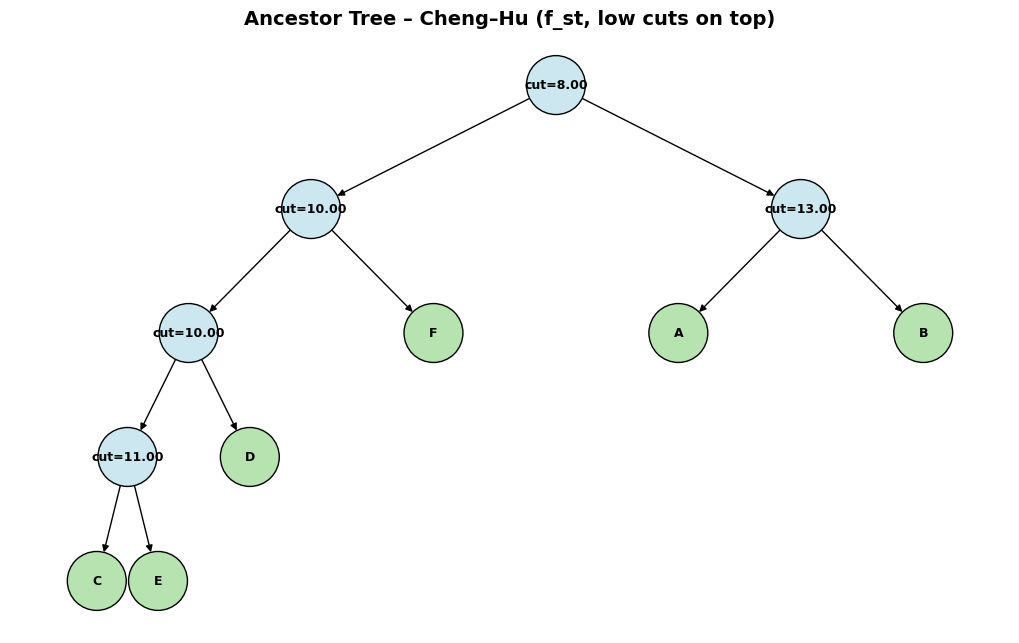

In [ ]:
edges = [
    ("A", "B", 9),
    ("A", "D", 4),
    ("B", "C", 4),
    ("D", "C", 6),
    ("C", "E", 3),
    ("D", "F", 2)
]

G = nx.Graph()
for u, v, w in edges:
    G.add_edge(u, v, capacity=w)

root = build_ancestor_tree_fst(G, "C", "B", seed=7)
plot_ancestor_tree(root)


Min-cut chiamati: 10 ≈ 10 attesi


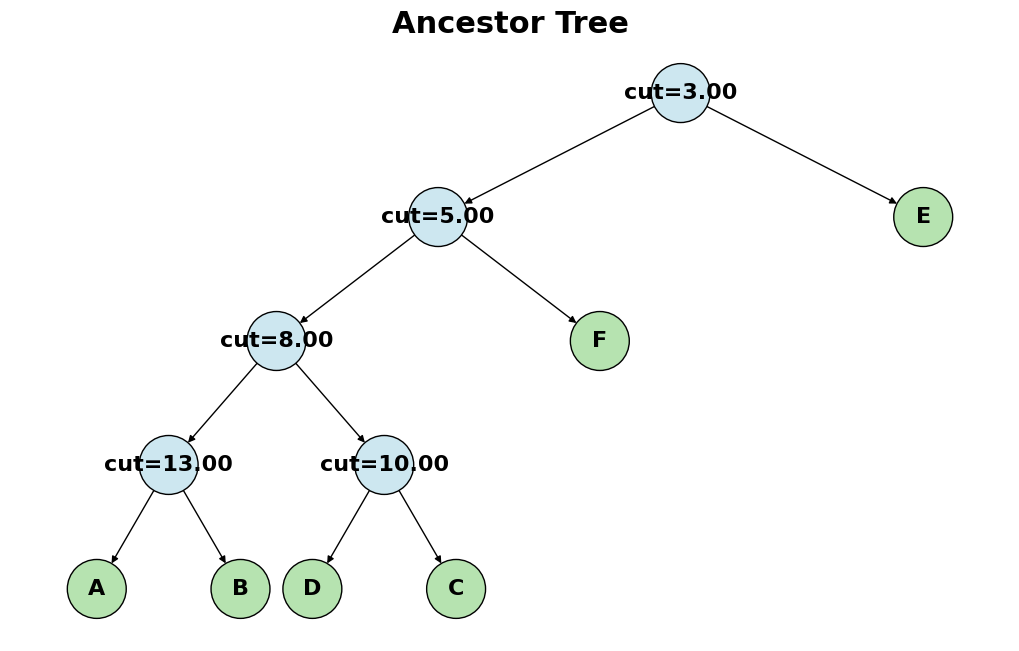

<Figure size 640x480 with 0 Axes>

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# ============================================================
# 1️⃣ GRAFO DI ESEMPIO
# ============================================================

edges = [
    ("A", "B", 9),
    ("A", "D", 4),
    ("B", "C", 4),
    ("D", "C", 6),
    ("C", "E", 3),
    ("D", "F", 2)
]

G = nx.Graph()
for u, v, w in edges:
    G.add_edge(u, v, capacity=w)

s, t = "A", "E"

# ============================================================
# 2️⃣ FUNZIONI BASE
# ============================================================

def total_capacity(Gu):
    return sum(float(data.get("capacity", 0.0)) for _, _, data in Gu.edges(data=True))

CUT_CALLS = {"count": 0}

def mincut_fst_inplace(Gu, s, t, x, y, M):
    """Esegue i due tagli f_st(x,y) e f_st(y,x) come in Cheng–Hu"""
    if x == y:
        return (0.0, ({x}, set(Gu.nodes()) - {x}))
    CUT_CALLS["count"] += 2

    addedA = []
    for a, b in [(x, s), (y, t)]:
        if Gu.has_edge(a, b):
            Gu[a][b]["capacity"] += M
            addedA.append((a, b, M, True))
        else:
            Gu.add_edge(a, b, capacity=M)
            addedA.append((a, b, M, False))
    v1, part1 = nx.minimum_cut(Gu, s, t, capacity="capacity")
    for a, b, cap, existed in addedA:
        if existed:
            Gu[a][b]["capacity"] -= cap
        else:
            Gu.remove_edge(a, b)

    addedB = []
    for a, b in [(x, t), (y, s)]:
        if Gu.has_edge(a, b):
            Gu[a][b]["capacity"] += M
            addedB.append((a, b, M, True))
        else:
            Gu.add_edge(a, b, capacity=M)
            addedB.append((a, b, M, False))
    v2, part2 = nx.minimum_cut(Gu, s, t, capacity="capacity")
    for a, b, cap, existed in addedB:
        if existed:
            Gu[a][b]["capacity"] -= cap
        else:
            Gu.remove_edge(a, b)

    return (v1, part1) if v1 <= v2 else (v2, part2)

# ============================================================
# 3️⃣ NODO DELL'ALBERO
# ============================================================

class ATNode:
    def __init__(self, members):
        self.members = set(members)
        self.value = None
        self.left = None
        self.right = None
        self.parent = None

# ============================================================
# 4️⃣ COSTRUZIONE DELL'ALBERO (CHENG–HU)
# ============================================================

def build_ancestor_tree_cheng_hu_with_restructuring(Gu, s, t, seed=42, tol=1.0):
    random.seed(seed)
    all_nodes = list(Gu.nodes())
    root = ATNode(all_nodes)
    M = total_capacity(Gu) + 1.0
    seeds = {random.choice(all_nodes)}
    cuts_done = 0
    leaves = [root]

    def pick_unseed(L):
        for z in sorted(L.members):
            if z not in seeds:
                return z
        return None

    def find_insertion_point(start_node, cut_value):
        x = start_node
        while (
            x.parent is not None
            and x.parent.value is not None
            and cut_value + tol < x.parent.value
        ):
            x = x.parent
        return x

    while cuts_done < len(all_nodes) - 1:
        leaf = next((L for L in leaves if any(z not in seeds for z in L.members)), None)
        if leaf is None:
            break
        p = next((z for z in sorted(leaf.members) if z in seeds), None)
        q = pick_unseed(leaf)
        if p is None or q is None:
            seeds |= set(leaf.members)
            leaves.remove(leaf)
            continue
        cut_value, part = mincut_fst_inplace(Gu, s, t, p, q, M)
        S, T = part
        left_members = {z for z in leaf.members if z in S}
        right_members = leaf.members - left_members

        if left_members and right_members:
            leaf.value = float(cut_value)
            Lnode = ATNode(left_members)
            Rnode = ATNode(right_members)
            Lnode.parent = leaf
            Rnode.parent = leaf
            leaf.left = Lnode
            leaf.right = Rnode
            leaves.remove(leaf)
            leaves += [Lnode, Rnode]
            seeds.add(p)
            seeds.add(q)
            cuts_done += 1
            continue

        insert_node = find_insertion_point(leaf, float(cut_value))
        A = {z for z in insert_node.members if z in S}
        B = insert_node.members - A
        if not A or not B:
            seeds |= set(leaf.members)
            leaves.remove(leaf)
            continue
        new_node = ATNode(insert_node.members)
        new_node.value = float(cut_value)
        Lnode = ATNode(A)
        Rnode = ATNode(B)
        Lnode.parent = new_node
        Rnode.parent = new_node
        new_node.left = Lnode
        new_node.right = Rnode

        parent = insert_node.parent
        if parent is not None:
            if parent.left is insert_node:
                parent.left = new_node
            else:
                parent.right = new_node
            new_node.parent = parent
        else:
            root = new_node
        seeds.add(p)
        seeds.add(q)
        cuts_done += 1

    print(f"Min-cut chiamati: {CUT_CALLS['count']} ≈ {2 * (len(all_nodes) - 1)} attesi")
    return root

# ============================================================
# 5️⃣ RIORDINO STRUTTURALE – cut minori in alto
# ============================================================

def reorder_tree_structure_by_value_balanced(node):
    """
    Riordina l'albero in modo che i valori più piccoli stiano in alto,
    ma mantiene la struttura binaria originale (senza catene o cicli).
    """
    if node is None:
        return None

    node.left = reorder_tree_structure_by_value_balanced(node.left)
    node.right = reorder_tree_structure_by_value_balanced(node.right)

    if node.left and node.left.value is not None and node.value is not None and node.left.value < node.value:
        left = node.left
        node.left = left.right
        left.right = node
        left.parent = node.parent
        node.parent = left
        return left

    if node.right and node.right.value is not None and node.value is not None and node.right.value < node.value:
        right = node.right
        node.right = right.left
        right.left = node
        right.parent = node.parent
        node.parent = right
        return right

    return node

# ============================================================
# 6️⃣ VISUALIZZAZIONE
# ============================================================

def build_tree_edges(node, edges=None, labels=None, parent=None):
    if edges is None:
        edges, labels = [], {}
    if parent:
        edges.append((parent, node))
    label = f"cut={node.value:.2f}" if node.value is not None else ",".join(sorted(node.members))
    labels[node] = label
    if node.left:
        build_tree_edges(node.left, edges, labels, node)
    if node.right:
        build_tree_edges(node.right, edges, labels, node)
    return edges, labels

def hierarchy_pos(G, root, x=0, y=0, layer_gap=1.0, spread=1.0):
    pos = {root: (x, -y)}
    children = list(G.successors(root))
    if not children:
        return pos
    dx = spread / len(children)
    next_x = x - spread / 2 + dx / 2
    for child in children:
        pos.update(hierarchy_pos(G, child, next_x, y + layer_gap, layer_gap, spread / 1.5))
        next_x += dx
    return pos

def plot_ancestor_tree(root):
    edges, labels = build_tree_edges(root)
    Gviz = nx.DiGraph()
    Gviz.add_edges_from(edges)
    pos = hierarchy_pos(Gviz, root)
    plt.figure(figsize=(10, 6))
    nx.draw(Gviz, pos,
            with_labels=False,
            node_size=1800,
            node_color=["#cde7f0" if n.value is not None else "#b6e3b0" for n in Gviz.nodes()],
            edgecolors="black")
    nx.draw_networkx_labels(Gviz, pos, {n: labels[n] for n in Gviz.nodes()}, font_size=16, font_weight="bold")
    plt.title("Ancestor Tree", fontsize=22, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

Gu = G.copy()
CUT_CALLS["count"] = 0
root = build_ancestor_tree_cheng_hu_with_restructuring(Gu, s, t, seed=42)
root = reorder_tree_structure_by_value_balanced(root)
plot_ancestor_tree(root)

# 🔽 Salva la figura che hai appena visto nell’output
plt.savefig("ancestor_tree_output.png", dpi=600, bbox_inches="tight")

# 🔽 Download automatico



